# EuroSAT Land Use and Land Cover Classification using Machine Learning and Deep Learning

**Group Members:** Jingqi Lu, Tessa Vu, Ming Cao
**Submission Date:** 2026-03-29

This notebook contains the complete assignment instructions and implementation for EuroSAT LULC classification with traditional ML and deep learning models.

## Assignment Instructions (Complete)

### 1. Data Loading, Processing, and Exploration
1.1 Data Preparation:
- Load EuroSAT data and perform basic EDA.
- Assess class distribution and plot one image from each class in a 2x5 grid.
- Flatten images to a 2D matrix (n x p), store data and labels in NumPy arrays.
- Split data into train (60%) and test (40%) with stratification.
- Create grayscale version for traditional ML and early deep learning models.

1.2 Data Augmentation:
- Apply augmentation before train/test split and preprocessing.
- Append augmented samples to original dataset and report new dataset size.
- Plot three random images and a label histogram of the full augmented dataset.

### 2. Traditional Machine Learning (Forest, Residential, Industrial only)
2.1 Binary SVM:
- Train linear SVM for [F vs R], [F vs I], [R vs I].
- Report accuracy, ROC, AUC.
- Show one misclassified image per binary classifier with prediction and ground truth.

2.2 Multiclass Majority-Vote SVM:
- Combine the three binary SVMs using majority vote.
- Report multiclass accuracy, ROC, AUC.
- Show one misclassified image from each class.

2.3 Multiclass Random Forest:
- Train on the same three-class grayscale subset.
- Report accuracy and confusion matrix.
- Show one misclassified image from each class.

### 3. Deep Learning
3.1 Grayscale Images (all 10 classes):
- 3.1.1 Single-layer fully connected network.
- 3.1.2 Two-layer fully connected network.
- 3.1.3 Four-layer fully connected network with dropout.
- Visualize architecture and report test accuracy for each model.
- Compare models, parameters, and epoch effects.
- Build ensemble from models 1-3 and evaluate.

3.2 RGB Images:
- 3.2.1 CNN model with Conv2D, MaxPooling2D, Dropout, Flatten, Dense.
- 3.2.2 Advanced model targeting best accuracy (for example transfer learning).
- Compare results and analyze top confusing classes with misclassified examples.

3.3 Multispectral Images:
- Apply best approach to EuroSAT multispectral images using more than RGB channels.
- Report test accuracy and compare with RGB results.

### 4. Reflection Questions
- Summarize parameter tuning lessons, epoch effects, dropout impact, ensemble behavior, challenges, and future improvements.

### 5. Submission Notes
- Submit as `assignments/eurosat.ipynb`.
- Put extra files in `assignments/eurosat_files/`.
- Run formatting/lint checks before submission.

In [39]:
# Core imports
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical, plot_model

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [40]:
# Paths and class names
CLASS_NAMES = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake",
]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}


def find_dataset_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for c in candidates:
        if (c / "EuroSAT_RGB").exists() and (c / "EuroSAT_MS").exists():
            return c
    raise FileNotFoundError("Could not find EuroSAT_RGB and EuroSAT_MS folders.")


DATA_ROOT = find_dataset_root()
RGB_ROOT = DATA_ROOT / "EuroSAT_RGB"
MS_ROOT = DATA_ROOT / "EuroSAT_MS"
IMG_SIZE = (64, 64)

print("DATA_ROOT:", DATA_ROOT)

DATA_ROOT: /Users/luchieeoo/Desktop/remote sensing/euro stat


In [41]:
# 1.1 Load RGB data
def load_rgb_dataset(root, class_names, image_size=(64, 64), max_per_class=None):
    # Returns image tensor (N, H, W, C), integer labels (N,), and file paths.
    images, labels, paths = [], [], []
    for cls in class_names:
        cls_dir = root / cls
        files = sorted(
            [
                p
                for p in cls_dir.iterdir()
                if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
            ]
        )
        if max_per_class is not None:
            files = files[:max_per_class]
        for fp in files:
            img = Image.open(fp).convert("RGB").resize(image_size)
            arr = np.asarray(img, dtype=np.uint8)
            images.append(arr)
            labels.append(CLASS_TO_IDX[cls])
            paths.append(fp)
    return np.array(images), np.array(labels), np.array(paths)


X_rgb, y, img_paths = load_rgb_dataset(RGB_ROOT, CLASS_NAMES, IMG_SIZE)
print("RGB data shape:", X_rgb.shape)
print("Labels shape:", y.shape)

RGB data shape: (27000, 64, 64, 3)
Labels shape: (27000,)


Class counts:
AnnualCrop               -> 3000
Forest                   -> 3000
HerbaceousVegetation     -> 3000
Highway                  -> 2500
Industrial               -> 2500
Pasture                  -> 2000
PermanentCrop            -> 2500
Residential              -> 3000
River                    -> 2500
SeaLake                  -> 3000


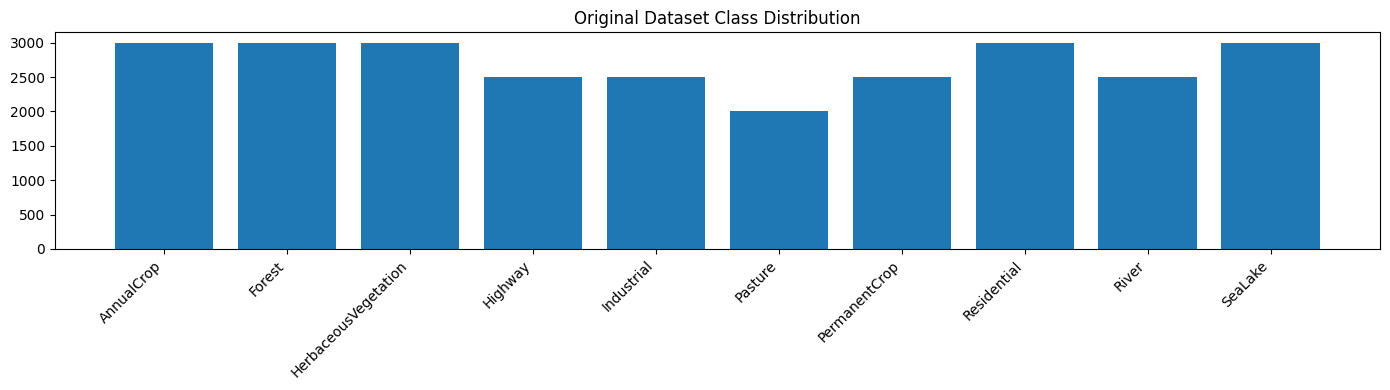

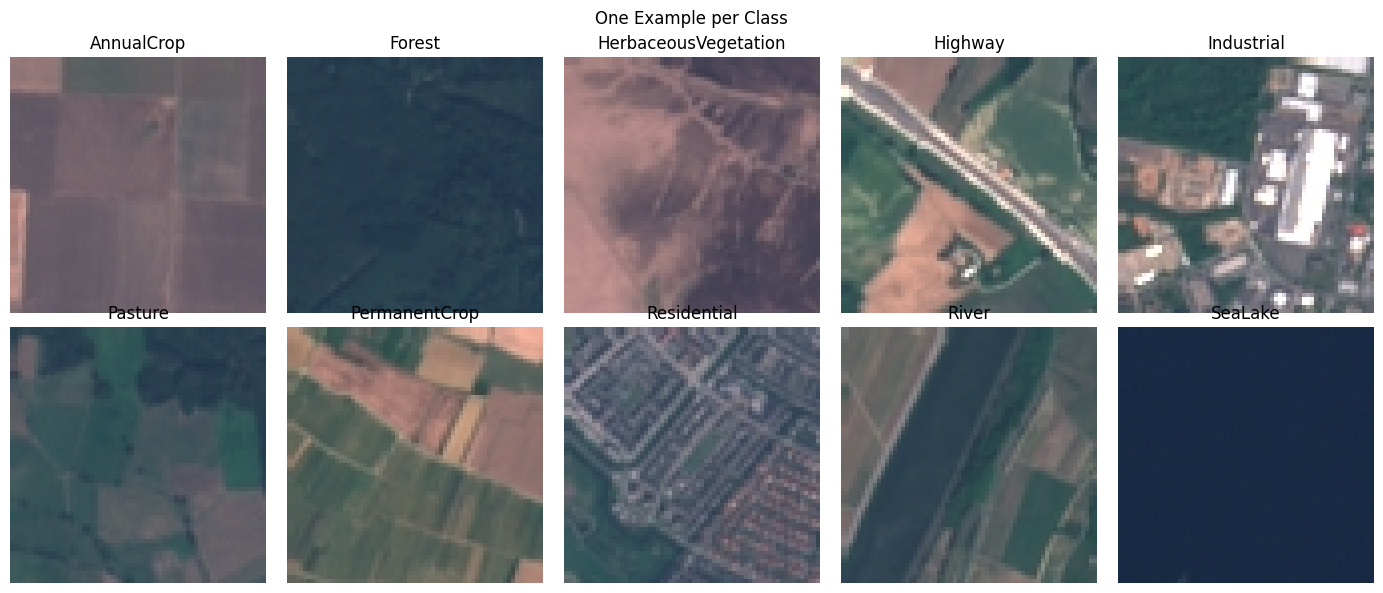

In [42]:
# 1.1 EDA: class distribution and one example per class
class_counts = {cls: int(np.sum(y == idx)) for cls, idx in CLASS_TO_IDX.items()}
print("Class counts:")
for cls in CLASS_NAMES:
    print(f"{cls:24s} -> {class_counts[cls]}")

plt.figure(figsize=(14, 4))
plt.bar(CLASS_NAMES, [class_counts[c] for c in CLASS_NAMES])
plt.xticks(rotation=45, ha="right")
plt.title("Original Dataset Class Distribution")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, cls in enumerate(CLASS_NAMES):
    idx = np.where(y == CLASS_TO_IDX[cls])[0][0]
    ax = axes[i // 5, i % 5]
    ax.imshow(X_rgb[idx])
    ax.set_title(cls)
    ax.axis("off")
plt.suptitle("One Example per Class")
plt.tight_layout()
plt.show()

In [43]:
# 1.2 Data augmentation BEFORE split
def simple_augment(img):
    # Deterministic + fast augmentation for reproducibility
    return [np.fliplr(img), np.rot90(img, k=1)]


aug_images = []
aug_labels = []
for img, label in zip(X_rgb, y):
    aug_images.append(img)
    aug_labels.append(label)
    for a in simple_augment(img):
        aug_images.append(a.astype(np.uint8))
        aug_labels.append(label)

X_aug = np.array(aug_images)
y_aug = np.array(aug_labels)
print("Original size:", len(X_rgb))
print("Augmented size:", len(X_aug))

Original size: 27000
Augmented size: 81000


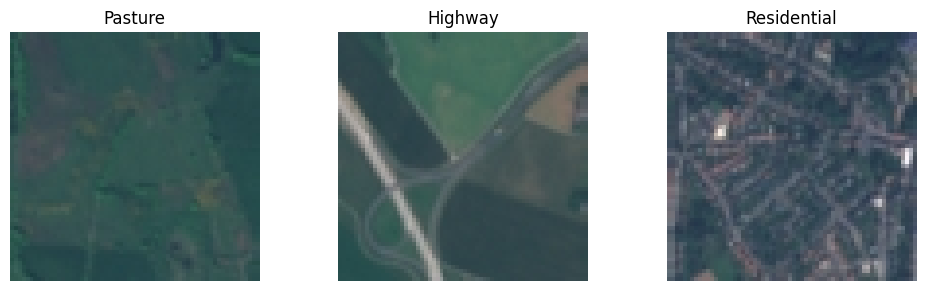

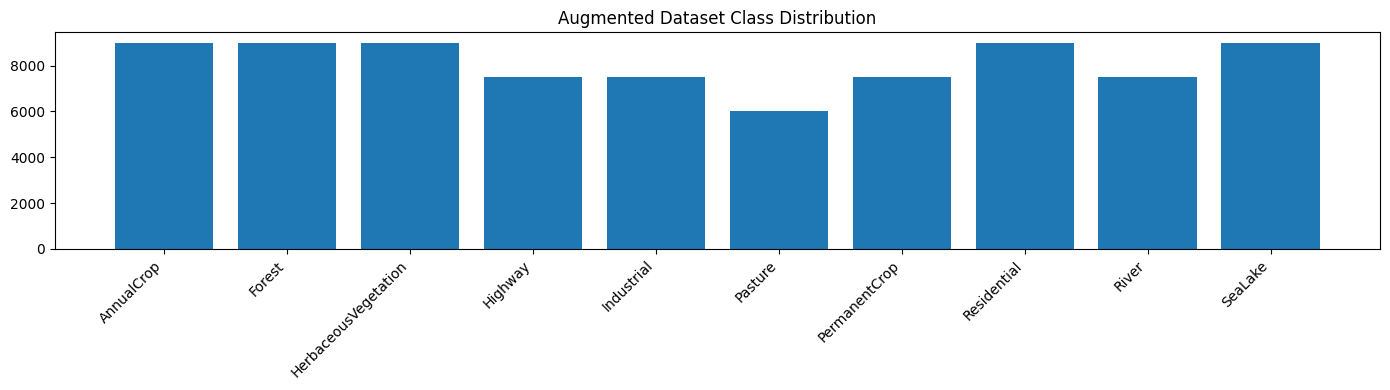

In [44]:
# 1.2 Plot 3 random images + histogram on augmented data
rand_idx = np.random.choice(len(X_aug), size=3, replace=False)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, idx in zip(axes, rand_idx):
    ax.imshow(X_aug[idx])
    ax.set_title(CLASS_NAMES[y_aug[idx]])
    ax.axis("off")
plt.tight_layout()
plt.show()

aug_counts = [int(np.sum(y_aug == i)) for i in range(len(CLASS_NAMES))]
plt.figure(figsize=(14, 4))
plt.bar(CLASS_NAMES, aug_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Augmented Dataset Class Distribution")
plt.tight_layout()
plt.show()

In [45]:
# 1.1 Split after augmentation and create grayscale
def rgb_to_grayscale(x):
    # ITU-R BT.601 luma transform
    return (0.299 * x[..., 0] + 0.587 * x[..., 1] + 0.114 * x[..., 2]).astype(np.uint8)


# Requirement alignment: build full NumPy matrices before splitting.
X_gray_full = rgb_to_grayscale(X_aug)
X_gray_flat_full = X_gray_full.reshape(len(X_gray_full), -1)
y_full = y_aug.copy()
print(
    "Full grayscale matrix (n x p):", X_gray_flat_full.shape, "| Labels:", y_full.shape
)

X_train_rgb, X_test_rgb, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.4, random_state=RANDOM_SEED, stratify=y_aug
)

X_train_gray = rgb_to_grayscale(X_train_rgb)
X_test_gray = rgb_to_grayscale(X_test_rgb)

X_train_gray_flat = X_train_gray.reshape(len(X_train_gray), -1)
X_test_gray_flat = X_test_gray.reshape(len(X_test_gray), -1)

print("Train RGB:", X_train_rgb.shape, "Test RGB:", X_test_rgb.shape)
print("Train gray:", X_train_gray.shape, "Test gray:", X_test_gray.shape)
print("Flattened train matrix (n x p):", X_train_gray_flat.shape)

Full grayscale matrix (n x p): (81000, 4096) | Labels: (81000,)
Train RGB: (48600, 64, 64, 3) Test RGB: (32400, 64, 64, 3)
Train gray: (48600, 64, 64) Test gray: (32400, 64, 64)
Flattened train matrix (n x p): (48600, 4096)


### 1.1 Summary: Data Preparation

In this section, the EuroSAT RGB dataset was loaded into NumPy arrays together with the corresponding class labels and file paths. Basic exploratory analysis was then carried out to verify class balance and data quality. In particular, the class distribution was inspected across all ten land-cover categories, and one representative image from each class was visualised in a 2x5 grid to provide an initial qualitative overview of the dataset.

For the downstream classical machine learning models, the RGB images were further converted to grayscale and reshaped into a two-dimensional feature matrix of size $(n, p)$. The dataset was then partitioned into training and test subsets using a 60/40 stratified split so that class proportions remained consistent across both sets. This preprocessing stage established a common data structure for the later traditional machine learning and deep learning experiments.

## 2. Traditional Machine Learning (Forest, Residential, Industrial only)

In [46]:
# Subset to F, R, I classes on grayscale data
fri_classes = ["Forest", "Residential", "Industrial"]
fri_ids = [CLASS_TO_IDX[c] for c in fri_classes]

train_mask = np.isin(y_train, fri_ids)
test_mask = np.isin(y_test, fri_ids)

X_train_fri = X_train_gray_flat[train_mask]
y_train_fri = y_train[train_mask]
X_test_fri = X_test_gray_flat[test_mask]
y_test_fri = y_test[test_mask]

print("FRI train:", X_train_fri.shape, "FRI test:", X_test_fri.shape)

FRI train: (15300, 4096) FRI test: (10200, 4096)


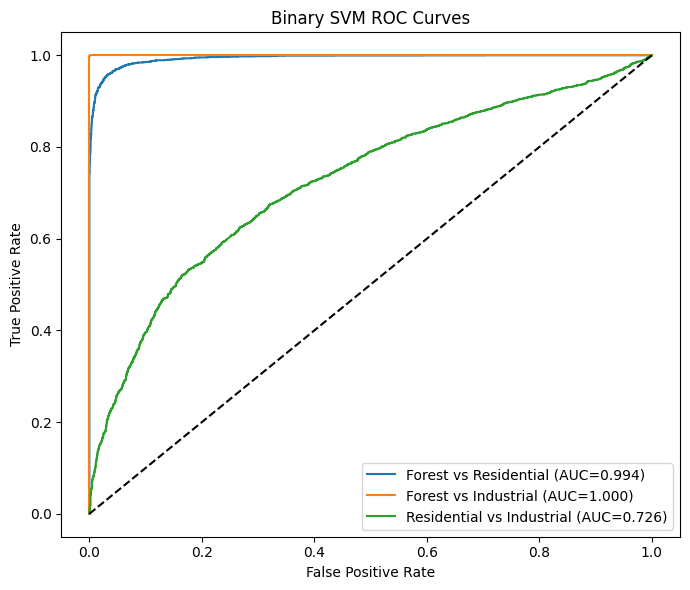

Forest vs Residential    | Accuracy=0.9469 | AUC=0.9939
Forest vs Industrial     | Accuracy=0.9973 | AUC=1.0000
Residential vs Industrial | Accuracy=0.6783 | AUC=0.7257


In [47]:
# 2.1 Binary SVMs: [F vs R], [F vs I], [R vs I]
pairs = [
    ("Forest", "Residential"),
    ("Forest", "Industrial"),
    ("Residential", "Industrial"),
]
binary_results = {}
binary_models = {}

fig, ax = plt.subplots(figsize=(7, 6))

for a, b in pairs:
    id_a, id_b = CLASS_TO_IDX[a], CLASS_TO_IDX[b]
    tr = np.isin(y_train_fri, [id_a, id_b])
    te = np.isin(y_test_fri, [id_a, id_b])

    Xtr, ytr = X_train_fri[tr], y_train_fri[tr]
    Xte, yte = X_test_fri[te], y_test_fri[te]

    ytr_bin = (ytr == id_b).astype(int)
    yte_bin = (yte == id_b).astype(int)

    svm = SVC(kernel="linear", probability=True, random_state=RANDOM_SEED)
    svm.fit(Xtr, ytr_bin)

    pred = svm.predict(Xte)
    prob = svm.predict_proba(Xte)[:, 1]
    acc = accuracy_score(yte_bin, pred)
    fpr, tpr, _ = roc_curve(yte_bin, prob)
    pair_auc = auc(fpr, tpr)

    key = f"{a} vs {b}"
    binary_models[key] = (svm, id_a, id_b)
    binary_results[key] = {
        "accuracy": acc,
        "auc": pair_auc,
        "X_test": Xte,
        "y_true": yte_bin,
        "y_pred": pred,
    }

    ax.plot(fpr, tpr, label=f"{key} (AUC={pair_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--")
ax.set_title("Binary SVM ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

for k, v in binary_results.items():
    print(f"{k:24s} | Accuracy={v['accuracy']:.4f} | AUC={v['auc']:.4f}")


 Forest vs Residential


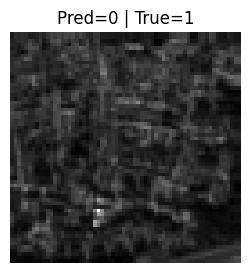


 Forest vs Industrial


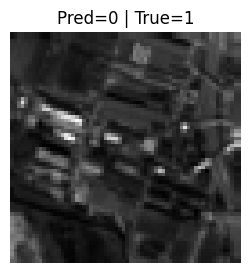


 Residential vs Industrial


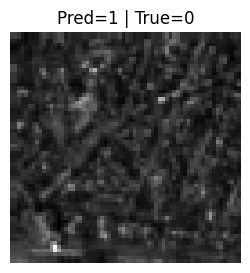

In [ ]:
# 2.1 Show one misclassified image for each binary classifier
for key, res in binary_results.items():
    wrong = np.where(res["y_true"] != res["y_pred"])[0]
    print("\n", key)
    if len(wrong) == 0:
        print("No misclassifications found for this classifier.")
        continue
    i = wrong[0]
    class_a, class_b = key.split(" vs ")
    pred_name = class_a if res["y_pred"][i] == 0 else class_b
    true_name = class_a if res["y_true"][i] == 0 else class_b
    img = res["X_test"][i].reshape(64, 64)
    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap="gray")
    plt.title(f"Pred: {pred_name}\nTrue: {true_name}", fontsize=9)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

Majority-vote multiclass accuracy: 0.769


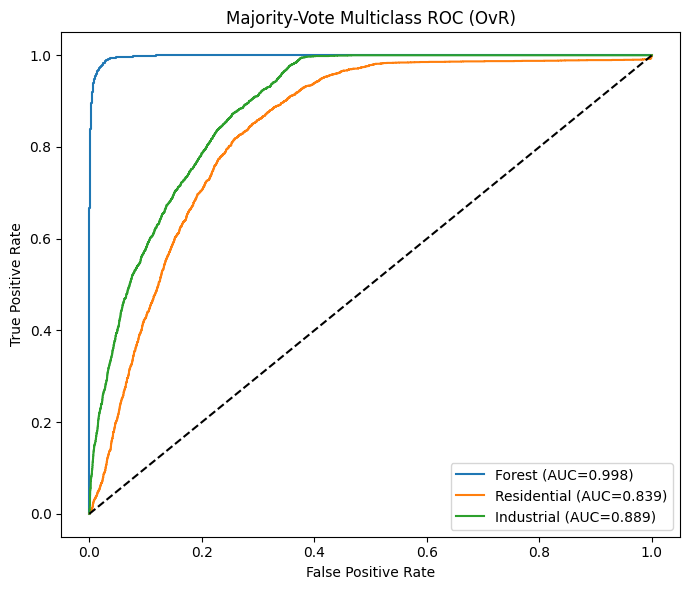

Per-class AUC:
Forest      : 0.9981
Residential : 0.8388
Industrial  : 0.8889
Macro AUC: 0.9086


In [49]:
# 2.2 Multiclass majority-vote from three binary SVMs
def majority_vote_predict(X):
    # Hard votes are used for final decision; soft scores are used for tie-break and ROC/AUC.
    votes = np.zeros((len(X), len(fri_ids)), dtype=int)
    soft_scores = np.zeros((len(X), len(fri_ids)), dtype=float)
    class_pos = {cid: i for i, cid in enumerate(fri_ids)}

    for _, (model, id_a, id_b) in binary_models.items():
        pred_bin = model.predict(X)
        proba_b = model.predict_proba(X)[:, 1]
        proba_a = 1.0 - proba_b

        mapped = np.where(pred_bin == 0, id_a, id_b)
        for i, cid in enumerate(mapped):
            votes[i, class_pos[cid]] += 1

        soft_scores[:, class_pos[id_a]] += proba_a
        soft_scores[:, class_pos[id_b]] += proba_b

    # Majority vote prediction
    pred_idx = votes.argmax(axis=1)

    # Tie handling: if votes are tied, use higher soft score among tied classes.
    max_votes = votes.max(axis=1, keepdims=True)
    tie_mask = (votes == max_votes).sum(axis=1) > 1
    if np.any(tie_mask):
        tie_rows = np.where(tie_mask)[0]
        for r in tie_rows:
            tied_cols = np.where(votes[r] == votes[r].max())[0]
            best_col = tied_cols[np.argmax(soft_scores[r, tied_cols])]
            pred_idx[r] = best_col

    pred_cid = np.array([fri_ids[i] for i in pred_idx])

    # Convert accumulated soft score to [0,1]-like class confidence for ROC curves.
    mv_score = soft_scores / len(binary_models)
    return pred_cid, mv_score, votes


mv_pred, mv_score, mv_votes = majority_vote_predict(X_test_fri)
mv_acc = accuracy_score(y_test_fri, mv_pred)
print("Majority-vote multiclass accuracy:", round(mv_acc, 4))

y_test_bin = label_binarize(y_test_fri, classes=fri_ids)
mv_auc = {}
plt.figure(figsize=(7, 6))
for i, cid in enumerate(fri_ids):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], mv_score[:, i])
    mv_auc[CLASS_NAMES[cid]] = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[cid]} (AUC={mv_auc[CLASS_NAMES[cid]]:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.title("Majority-Vote Multiclass ROC (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

macro_auc = float(np.mean(list(mv_auc.values())))
print("Per-class AUC:")
for cls_name in fri_classes:
    print(f"{cls_name:12s}: {mv_auc[cls_name]:.4f}")
print("Macro AUC:", round(macro_auc, 4))


Class: Forest


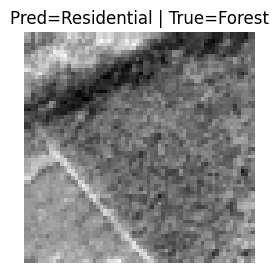

Votes -> Forest:1, Residential:2, Industrial:0

Class: Residential


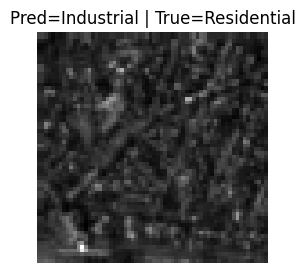

Votes -> Forest:0, Residential:1, Industrial:2

Class: Industrial


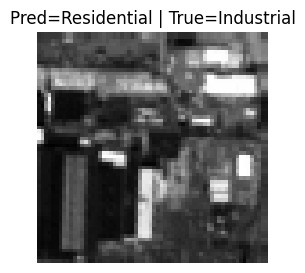

Votes -> Forest:0, Residential:2, Industrial:1


In [ ]:
# 2.2 One misclassified image from each class (majority vote)
for cid in fri_ids:
    cls_name = CLASS_NAMES[cid]
    idx = np.where((y_test_fri == cid) & (mv_pred != cid))[0]
    print("\nClass:", cls_name)
    if len(idx) == 0:
        print("No misclassified sample found for this class.")
        continue
    i = idx[0]
    vote_vec = mv_votes[i]
    vote_txt = ", ".join(
        [f"{fri_classes[j]}:{vote_vec[j]}" for j in range(len(fri_classes))]
    )

    plt.figure(figsize=(3, 3))
    plt.imshow(X_test_fri[i].reshape(64, 64), cmap="gray")
    plt.title(f"Pred: {CLASS_NAMES[mv_pred[i]]}\nTrue: {cls_name}", fontsize=9)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    print("Votes ->", vote_txt)

Random Forest accuracy: 0.9245

Per-class classification report:
              precision    recall  f1-score   support

      Forest       0.99      0.99      0.99      3600
 Residential       0.90      0.88      0.89      3600
  Industrial       0.88      0.90      0.89      3000

    accuracy                           0.92     10200
   macro avg       0.92      0.92      0.92     10200
weighted avg       0.92      0.92      0.92     10200



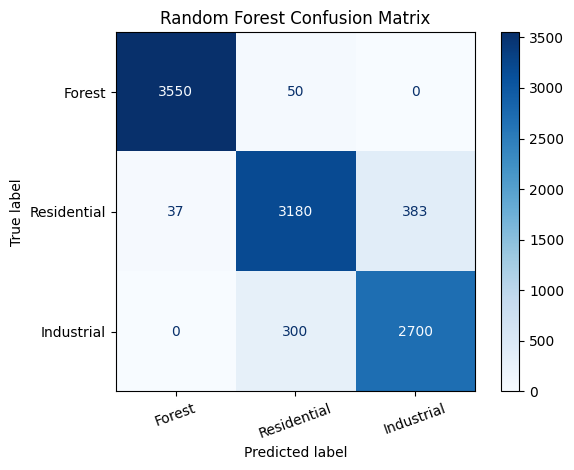

In [51]:
# 2.3 Multiclass Random Forest
# n_estimators=300 provides stable estimates; n_jobs=-1 uses all CPU cores.
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train_fri, y_train_fri)
rf_pred = rf.predict(X_test_fri)
rf_acc = accuracy_score(y_test_fri, rf_pred)
print("Random Forest accuracy:", round(rf_acc, 4))

from sklearn.metrics import classification_report

print("\nPer-class classification report:")
print(
    classification_report(
        y_test_fri,
        rf_pred,
        labels=fri_ids,
        target_names=fri_classes,
    )
)

cm = confusion_matrix(y_test_fri, rf_pred, labels=fri_ids)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[CLASS_NAMES[i] for i in fri_ids]
)
disp.plot(cmap="Blues", xticks_rotation=20)
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


Class: Forest


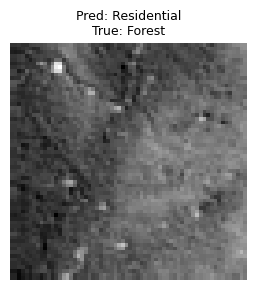


Class: Residential


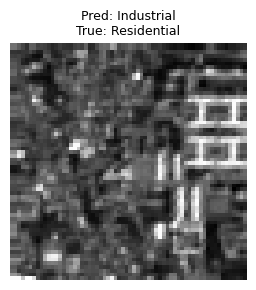


Class: Industrial


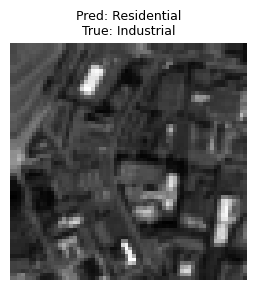

In [52]:
# 2.3 One misclassified image from each class (RF)
for cid in fri_ids:
    cls_name = CLASS_NAMES[cid]
    idx = np.where((y_test_fri == cid) & (rf_pred != cid))[0]
    print(f"\nClass: {cls_name}")
    if len(idx) == 0:
        print("No misclassified sample found for this class.")
        continue
    i = idx[0]
    pred_name = CLASS_NAMES[rf_pred[i]]
    plt.figure(figsize=(3, 3))
    plt.imshow(X_test_fri[i].reshape(64, 64), cmap="gray")
    plt.title(f"Pred: {pred_name}\nTrue: {cls_name}", fontsize=9)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

### 2 Summary: Traditional Machine Learning

This section examined three classical machine learning approaches for distinguishing the Forest, Residential, and Industrial classes using flattened grayscale pixel values as input features. Restricting the task to these three categories made it possible to compare linear decision boundaries, majority-vote aggregation, and a non-linear ensemble model under the same feature representation.

The pairwise linear SVM experiments showed that class separability was not uniform across the three binary tasks. Forest was comparatively easy to distinguish from the other two classes, whereas Residential and Industrial were more difficult to separate, reflecting the greater visual similarity between built-up land-cover categories in grayscale imagery. Extending the three binary SVMs into a multiclass majority-vote scheme yielded an overall accuracy of 0.769 and a macro AUC of 0.91. The added soft-score tie-breaking step reduced the class-order bias that would otherwise arise when the vote count was tied.

The Random Forest model provided the strongest result within this section, reaching an accuracy of 0.9245 on the same three-class problem. This improvement suggests that non-linear decision boundaries are more suitable than linear ones for this representation. At the same time, the confusion matrix and class-wise results indicate that Residential and Industrial remain the primary source of error, which is consistent with the ambiguity already observed in the SVM-based analysis.

## 3. Deep Learning

In [53]:
# Shared preprocessing for deep learning
NUM_CLASSES = len(CLASS_NAMES)

Xtr_gray_nn = X_train_gray.astype("float32") / 255.0
Xte_gray_nn = X_test_gray.astype("float32") / 255.0

Xtr_gray_flat = Xtr_gray_nn.reshape(len(Xtr_gray_nn), -1)
Xte_gray_flat = Xte_gray_nn.reshape(len(Xte_gray_nn), -1)

ytr_ohe = to_categorical(y_train, NUM_CLASSES)
yte_ohe = to_categorical(y_test, NUM_CLASSES)

Xtr_rgb_nn = X_train_rgb.astype("float32") / 255.0
Xte_rgb_nn = X_test_rgb.astype("float32") / 255.0

In [54]:
# Helpers for training and architecture export
def compile_and_train(
    model, Xtr, ytr, Xte, yte, epochs=10, batch_size=64, name="model"
):
    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    history = model.fit(
        Xtr,
        ytr,
        validation_data=(Xte, yte),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
    )
    loss, acc = model.evaluate(Xte, yte, verbose=0)
    print(f"{name} test accuracy: {acc:.4f}")
    return history, acc


def try_plot_model(model, out_file):
    try:
        plot_model(model, to_file=out_file, show_shapes=True, show_dtype=False)
        print(f"Saved architecture to {out_file}")
    except Exception as e:
        print(
            "Could not export model architecture. Install pydot + graphviz if needed."
        )
        print("Reason:", e)

In [55]:
# 3.1.1 Single-layer NN (input -> softmax output)
model1 = models.Sequential(
    [layers.Input(shape=(64 * 64,)), layers.Dense(NUM_CLASSES, activation="softmax")]
)

hist1, acc1 = compile_and_train(
    model1, Xtr_gray_flat, ytr_ohe, Xte_gray_flat, yte_ohe, epochs=10, name="Model 1"
)
try_plot_model(model1, "assignments/eurosat_files/model1_arch.png")
params1 = model1.count_params()
print("Model 1 params:", params1)

Epoch 1/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1400 - loss: 2.3275 - val_accuracy: 0.1810 - val_loss: 2.2526
Epoch 2/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.1877 - loss: 2.2236 - val_accuracy: 0.2010 - val_loss: 2.2125
Epoch 3/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2179 - loss: 2.1790 - val_accuracy: 0.1995 - val_loss: 2.1807
Epoch 4/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2350 - loss: 2.1426 - val_accuracy: 0.1967 - val_loss: 2.1547
Epoch 5/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2450 - loss: 2.1121 - val_accuracy: 0.1945 - val_loss: 2.1333
Epoch 6/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2509 - loss: 2.0863 - val_accuracy: 0.1936 - val_loss: 2.1157
Epoch 7/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2562 - loss: 2.0641 - val_accuracy: 0.1933 - val_loss: 2.1013
Epoch 8/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2607 - loss: 2.0450 - val_acc

In [56]:
# 3.1.2 Two-layer NN
model2 = models.Sequential(
    [
        layers.Input(shape=(64 * 64,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ]
)

hist2, acc2 = compile_and_train(
    model2, Xtr_gray_flat, ytr_ohe, Xte_gray_flat, yte_ohe, epochs=10, name="Model 2"
)
try_plot_model(model2, "assignments/eurosat_files/model2_arch.png")
params2 = model2.count_params()
print("Model 2 params:", params2)

Epoch 1/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.1294 - loss: 2.8094 - val_accuracy: 0.1940 - val_loss: 2.2285
Epoch 2/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1893 - loss: 2.2594 - val_accuracy: 0.1939 - val_loss: 2.1783
Epoch 3/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2241 - loss: 2.1706 - val_accuracy: 0.1872 - val_loss: 2.1528
Epoch 4/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2369 - loss: 2.0984 - val_accuracy: 0.1619 - val_loss: 2.1828
Epoch 5/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2455 - loss: 2.0462 - val_accuracy: 0.1606 - val_loss: 2.1316
Epoch 6/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2509 - loss: 2.0145 - val_accuracy: 0.1679 - val_loss: 2.0672
Epoch 7/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.2538 - loss: 2.0029 - val_accuracy: 0.1675 - val_loss: 2.1010
Epoch 8/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.2560 - loss: 1.9995 - 

In [57]:
# 3.1.3 Four-layer NN with dropout
model3 = models.Sequential(
    [
        layers.Input(shape=(64 * 64,)),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ]
)

hist3, acc3 = compile_and_train(
    model3, Xtr_gray_flat, ytr_ohe, Xte_gray_flat, yte_ohe, epochs=12, name="Model 3"
)
try_plot_model(model3, "assignments/eurosat_files/model3_arch.png")
params3 = model3.count_params()
print("Model 3 params:", params3)

Epoch 1/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.1034 - loss: 41.8013 - val_accuracy: 0.0926 - val_loss: 28.6439
Epoch 2/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.0998 - loss: 69.7518 - val_accuracy: 0.1111 - val_loss: 50.6927
Epoch 3/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.1044 - loss: 42.5714 - val_accuracy: 0.1111 - val_loss: 29.0256
Epoch 4/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.1074 - loss: 28.3350 - val_accuracy: 0.1112 - val_loss: 15.8543
Epoch 5/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.1212 - loss: 21.5584 - val_accuracy: 0.0743 - val_loss: 35.6212
Epoch 6/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.1229 - loss: 23.4433 - val_accuracy: 0.0976 - val_loss: 20.9832
Epoch 7/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.1288 - loss: 19.4075 - val_accuracy: 0.1745 - val_loss: 10.9536
Epoch 8/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.1286 - l

Model parameter counts:
Model 1: 40,970
Model 2: 1,051,402 (margin vs M1: 1,010,432)
Model 3: 2,263,178 (margin vs M2: 1,211,776)
Best grayscale model: Model 1 with accuracy 0.1786


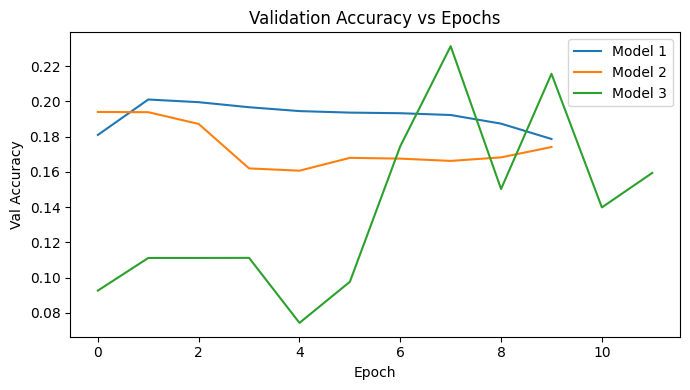

In [58]:
# 3.1.4 Comparison, parameter margins, and simple epoch effect plot
print("Model parameter counts:")
print(f"Model 1: {params1:,}")
print(f"Model 2: {params2:,} (margin vs M1: {params2 - params1:,})")
print(f"Model 3: {params3:,} (margin vs M2: {params3 - params2:,})")

accs = {"Model 1": acc1, "Model 2": acc2, "Model 3": acc3}
best_gray_name = max(accs, key=accs.get)
print(
    "Best grayscale model:",
    best_gray_name,
    "with accuracy",
    round(accs[best_gray_name], 4),
)

plt.figure(figsize=(7, 4))
for h, name in [(hist1, "Model 1"), (hist2, "Model 2"), (hist3, "Model 3")]:
    plt.plot(h.history["val_accuracy"], label=name)
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### 3.1 Observations: Fully Connected Networks on Grayscale Images

The results in this section indicate that fully connected networks are poorly suited to this classification problem when the input is represented as flattened grayscale pixels. Models 1-3 achieved test accuracies of 0.1786, 0.1741, and 0.1594 respectively, which are only marginally above the random baseline of 0.10 for a ten-class task. Increasing network depth therefore did not translate into better predictive performance.

Two factors appear to explain this behaviour. First, flattening the image removes the spatial organisation of the scene. Once the 64x64 image is converted into a one-dimensional vector, local structures such as edges, texture transitions, roof patterns, field boundaries, and road geometry are no longer represented explicitly. A dense network can still fit combinations of pixel intensities, but it does not exploit the local spatial correlations that are central to image interpretation. Second, converting the images to grayscale discards colour information that is highly informative in EuroSAT. Several classes, especially water, vegetation, and crop-related categories, become substantially harder to distinguish once hue information is removed.

Taken together, these results suggest that the low performance is not primarily a matter of insufficient parameter tuning. Rather, it reflects a mismatch between the model class and the data modality. This provides a clear motivation for moving to convolutional architectures in the next section, where both spatial structure and RGB information are retained.

In [59]:
# 3.1.4 Ensemble of models 1-3 by probability averaging
p1 = model1.predict(Xte_gray_flat, verbose=0)
p2 = model2.predict(Xte_gray_flat, verbose=0)
p3 = model3.predict(Xte_gray_flat, verbose=0)
p_ens = (p1 + p2 + p3) / 3.0
y_ens = p_ens.argmax(axis=1)
ens_acc = accuracy_score(y_test, y_ens)
print("Ensemble (models 1-3) accuracy:", round(ens_acc, 4))

Ensemble (models 1-3) accuracy: 0.2103


In [60]:
# 3.2.1 CNN on RGB
model4 = models.Sequential(
    [
        layers.Input(shape=(64, 64, 3)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ]
)

hist4, acc4 = compile_and_train(
    model4, Xtr_rgb_nn, ytr_ohe, Xte_rgb_nn, yte_ohe, epochs=12, name="Model 4 (CNN)"
)
try_plot_model(model4, "assignments/eurosat_files/model4_arch.png")
print("Model 4 params:", model4.count_params())

Epoch 1/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.3663 - loss: 1.7576 - val_accuracy: 0.7000 - val_loss: 0.8470
Epoch 2/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6621 - loss: 0.9922 - val_accuracy: 0.7342 - val_loss: 0.7390
Epoch 3/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.7015 - loss: 0.8833 - val_accuracy: 0.7809 - val_loss: 0.6441
Epoch 4/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.7301 - loss: 0.8042 - val_accuracy: 0.7703 - val_loss: 0.7188
Epoch 5/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.7353 - loss: 0.8089 - val_accuracy: 0.8001 - val_loss: 0.5939
Epoch 6/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.7473 - loss: 0.7798 - val_accuracy: 0.7448 - val_loss: 0.8006
Epoch 7/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.7445 - loss: 0.7958 - val_accuracy: 0.8035 - val_loss: 0.6043
Epoch 8/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.7549 - loss: 0.7726 - 

In [61]:
# 3.2.2 Advanced model: transfer learning (MobileNetV2)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

Xtr_m = preprocess_input((X_train_rgb.astype("float32")))
Xte_m = preprocess_input((X_test_rgb.astype("float32")))

base = MobileNetV2(include_top=False, weights="imagenet", input_shape=(64, 64, 3))
base.trainable = False

inputs = layers.Input(shape=(64, 64, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model5 = tf.keras.Model(inputs, outputs)

hist5, acc5 = compile_and_train(
    model5,
    Xtr_m,
    ytr_ohe,
    Xte_m,
    yte_ohe,
    epochs=8,
    batch_size=64,
    name="Model 5 (Transfer)",
)
try_plot_model(model5, "assignments/eurosat_files/model5_arch.png")

print("Model 5 params:", model5.count_params())

/var/folders/3f/gvmb3pz567x7nnmh7hs1rkg40000gn/T/ipykernel_3268/3867506379.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(include_top=False, weights="imagenet", input_shape=(64, 64, 3))


Epoch 1/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - accuracy: 0.6861 - loss: 0.9777 - val_accuracy: 0.8624 - val_loss: 0.4291
Epoch 2/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.8471 - loss: 0.4679 - val_accuracy: 0.8719 - val_loss: 0.3908
Epoch 3/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.8583 - loss: 0.4268 - val_accuracy: 0.8754 - val_loss: 0.3811
Epoch 4/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step - accuracy: 0.8611 - loss: 0.4159 - val_accuracy: 0.8766 - val_loss: 0.3821
Epoch 5/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.8655 - loss: 0.4100 - val_accuracy: 0.8767 - val_loss: 0.3803
Epoch 6/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.8673 - loss: 0.4006 - val_accuracy: 0.8782 - val_loss: 0.3742
Epoch 7/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.8674 - loss: 0.3946 - val_accuracy: 0.8776 - val_loss: 0.3749
Epoch 8/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.8680 - loss: 0.3905 - val_accu

Best RGB model: Model 5 Transfer accuracy: 0.8793


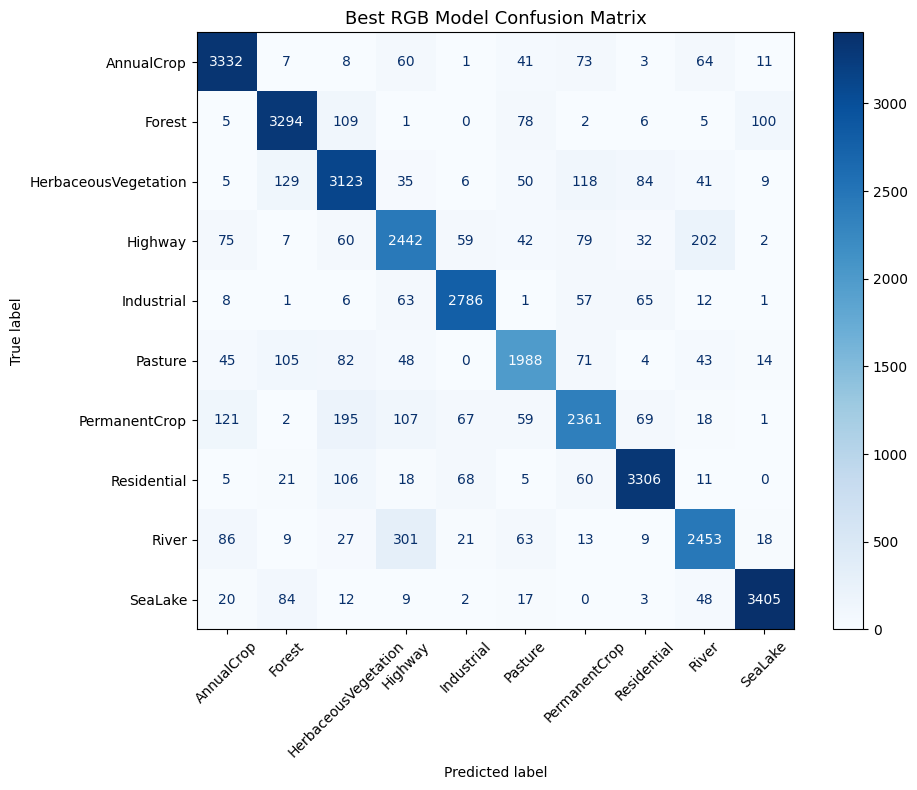

Top-2 most confused true->pred pairs:
True River -> Pred Highway: 301 samples
True Highway -> Pred River: 202 samples


In [62]:
# 3.2.2 Best RGB model and top-2 confusion pairs
rgb_scores = {"Model 4 CNN": acc4, "Model 5 Transfer": acc5}
best_rgb_name = max(rgb_scores, key=rgb_scores.get)
best_rgb_acc = rgb_scores[best_rgb_name]
print("Best RGB model:", best_rgb_name, "accuracy:", round(best_rgb_acc, 4))

if best_rgb_name == "Model 4 CNN":
    y_pred_best = model4.predict(Xte_rgb_nn, verbose=0).argmax(axis=1)
else:
    y_pred_best = model5.predict(Xte_m, verbose=0).argmax(axis=1)

cm10 = confusion_matrix(y_test, y_pred_best, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(10, 8))
disp10 = ConfusionMatrixDisplay(confusion_matrix=cm10, display_labels=CLASS_NAMES)
disp10.plot(cmap="Blues", xticks_rotation=45, ax=ax)
ax.set_title("Best RGB Model Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

cm_off = cm10.copy()
np.fill_diagonal(cm_off, 0)
pairs = []
for _ in range(2):
    i, j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
    pairs.append((i, j, cm_off[i, j]))
    cm_off[i, j] = -1

print("Top-2 most confused true->pred pairs:")
for i, j, v in pairs:
    print(f"True {CLASS_NAMES[i]} -> Pred {CLASS_NAMES[j]}: {int(v)} samples")

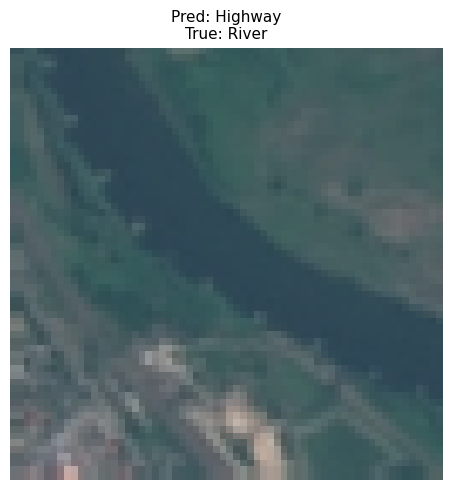

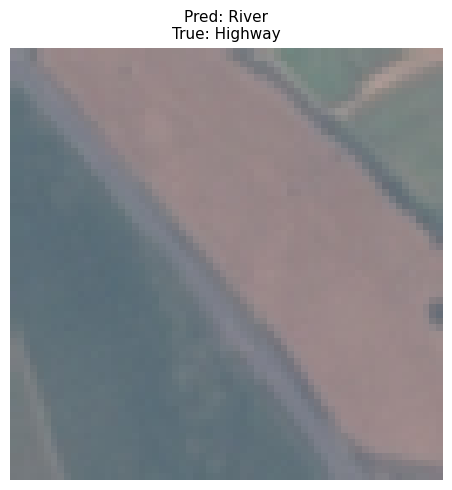

In [63]:
# Show misclassified examples for the top confusion pairs
for i, j, _ in pairs:
    idx = np.where((y_test == i) & (y_pred_best == j))[0]
    if len(idx) == 0:
        continue
    k = idx[0]
    plt.figure(figsize=(5, 5))
    plt.imshow(X_test_rgb[k])
    plt.title(f"Pred: {CLASS_NAMES[j]}\nTrue: {CLASS_NAMES[i]}", fontsize=11)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

### 3.2 Observations: CNNs and Transfer Learning on RGB Images

Once the experiments moved from flattened grayscale inputs to RGB convolutional models, performance improved substantially. The compact CNN trained from scratch reached a test accuracy of 0.8263, which represents a large increase over the fully connected baselines in Section 3.1. This confirms that preserving spatial locality through convolution is much more appropriate for land-cover image classification than treating each pixel as an independent feature.

The transfer-learning model based on MobileNetV2 further improved performance to 0.8793, outperforming the custom CNN by roughly five percentage points. This gain is consistent with the expected benefit of pretrained visual features. Even though EuroSAT differs from the natural-image domain on which ImageNet models are trained, the pretrained backbone still provides a stronger initial feature extractor than a model learned entirely from scratch on the task-specific data.

The confusion analysis also shows that the remaining errors are not distributed uniformly across classes. Most confusion is concentrated among categories with similar spectral and textural properties, especially crop and vegetation-related classes such as AnnualCrop, PermanentCrop, HerbaceousVegetation, and Pasture. By contrast, water bodies and several built-up classes remain comparatively well separated. This suggests that the residual errors are increasingly associated with fine-grained semantic overlap rather than a general failure of the model to capture image structure.

MS raw shape: (27000, 64, 64, 13)
Selected channels: [0, 1, 2, 7] -> input shape: (64, 64, 4)
Original MS size: 27000
Augmented MS size: 81000


/var/folders/3f/gvmb3pz567x7nnmh7hs1rkg40000gn/T/ipykernel_3268/203535734.py:62: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_ms = MobileNetV2(include_top=False, weights="imagenet", input_shape=(64, 64, 3))


Epoch 1/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 76s 83ms/step - accuracy: 0.6881 - loss: 0.9752 - val_accuracy: 0.8741 - val_loss: 0.3932 - learning_rate: 0.0010
Epoch 2/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 50s 65ms/step - accuracy: 0.8595 - loss: 0.4279 - val_accuracy: 0.8896 - val_loss: 0.3382 - learning_rate: 0.0010
Epoch 3/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 50s 65ms/step - accuracy: 0.8665 - loss: 0.3971 - val_accuracy: 0.8954 - val_loss: 0.3179 - learning_rate: 0.0010
Epoch 4/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 50s 65ms/step - accuracy: 0.8761 - loss: 0.3739 - val_accuracy: 0.9006 - val_loss: 0.3037 - learning_rate: 0.0010
Epoch 5/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 51s 68ms/step - accuracy: 0.8795 - loss: 0.3601 - val_accuracy: 0.9002 - val_loss: 0.3048 - learning_rate: 0.0010
Epoch 6/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 53s 69ms/step - accuracy: 0.8793 - loss: 0.3543 - val_accuracy: 0.9028 - val_loss: 0.2981 - learning_rate: 0.0010
Epoch 7/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 55s 72ms/step - accuracy: 0.8787 - l

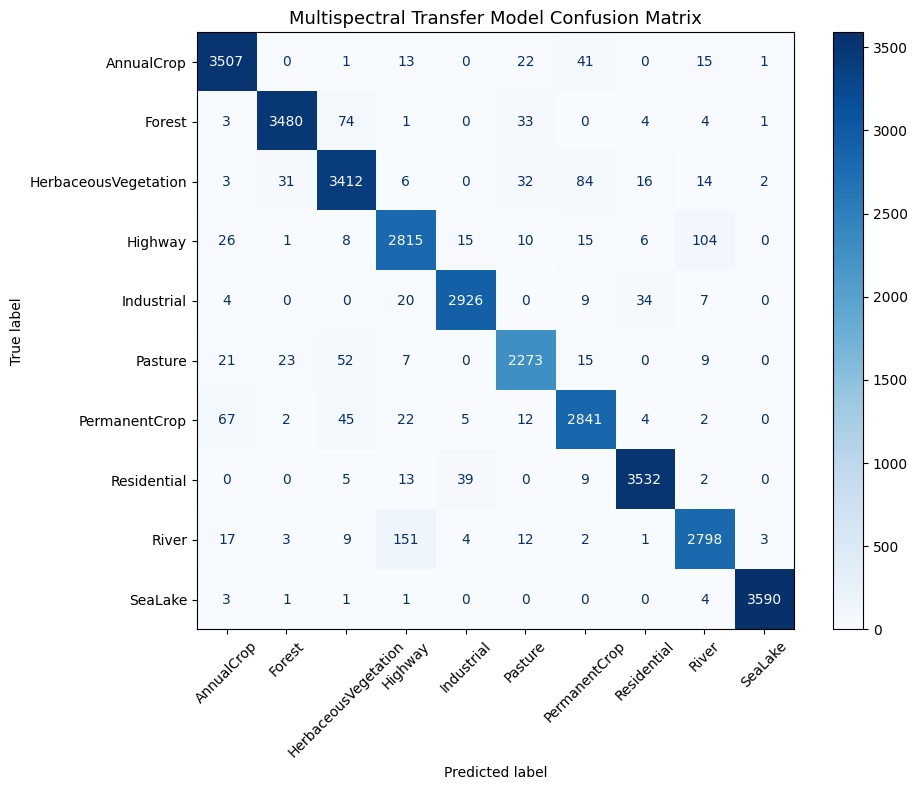

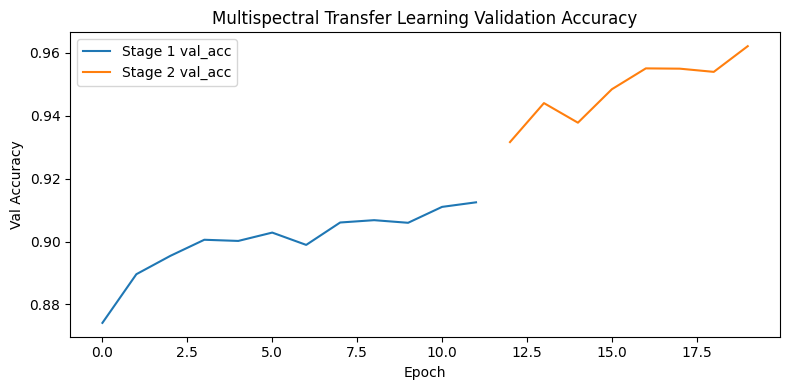

Multispectral test accuracy: 0.9622
Best RGB test accuracy:      0.8793


In [65]:
# 3.3 Multispectral: apply the best RGB idea to >3 channels via transfer learning
import imageio.v3 as iio
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


def load_ms_dataset(root, class_names, max_per_class=None):
    xs, ys = [], []
    for cls in class_names:
        cls_dir = root / cls
        files = sorted(
            [
                p
                for p in cls_dir.iterdir()
                if p.suffix.lower() in {".tif", ".tiff", ".png", ".jpg", ".jpeg"}
            ]
        )
        if max_per_class is not None:
            files = files[:max_per_class]
        for fp in files:
            arr = iio.imread(fp)
            if arr.ndim == 2:
                arr = arr[..., None]
            xs.append(arr)
            ys.append(CLASS_TO_IDX[cls])
    return np.array(xs), np.array(ys)


def simple_augment_ms(img):
    return [np.fliplr(img), np.rot90(img, k=1)]


X_ms, y_ms = load_ms_dataset(MS_ROOT, CLASS_NAMES, max_per_class=None)
print("MS raw shape:", X_ms.shape)

if X_ms.shape[-1] <= 3:
    raise ValueError(
        "Multispectral data appears to have <=3 channels. Please verify dataset files."
    )

# Use more than RGB by keeping visible bands plus one NIR-like channel.
selected_channels = [0, 1, 2, min(7, X_ms.shape[-1] - 1)]
X_ms_sel = X_ms[..., selected_channels].astype("float32")
print(f"Selected channels: {selected_channels} -> input shape: {X_ms_sel.shape[1:]}")

# Channel-wise normalization to [0, 1].
mins = X_ms_sel.min(axis=(0, 1, 2), keepdims=True)
maxs = X_ms_sel.max(axis=(0, 1, 2), keepdims=True)
X_ms_sel = (X_ms_sel - mins) / (maxs - mins + 1e-8)

# Match the RGB pipeline by augmenting before the split.
ms_aug_images = []
ms_aug_labels = []
for img, label in zip(X_ms_sel, y_ms):
    ms_aug_images.append(img)
    ms_aug_labels.append(label)
    for aug_img in simple_augment_ms(img):
        ms_aug_images.append(aug_img.astype("float32"))
        ms_aug_labels.append(label)

X_ms_aug = np.array(ms_aug_images, dtype="float32")
y_ms_aug = np.array(ms_aug_labels)
print("Original MS size:", len(X_ms_sel))
print("Augmented MS size:", len(X_ms_aug))

Xms_tr, Xms_te, yms_tr, yms_te = train_test_split(
    X_ms_aug, y_ms_aug, test_size=0.4, random_state=RANDOM_SEED, stratify=y_ms_aug
)

yms_tr_ohe = to_categorical(yms_tr, NUM_CLASSES)
yms_te_ohe = to_categorical(yms_te, NUM_CLASSES)

# Transfer-style multispectral model: learn a 4->3 projection, then reuse MobileNetV2.
base_ms = MobileNetV2(include_top=False, weights="imagenet", input_shape=(64, 64, 3))
base_ms.trainable = False

ms_inputs = layers.Input(shape=Xms_tr.shape[1:])
ms_proj = layers.Conv2D(3, 1, padding="same", use_bias=False, name="ms_projection")(
    ms_inputs
)
ms_proj = layers.BatchNormalization(name="ms_projection_bn")(ms_proj)
ms_rgb_like = layers.Lambda(
    lambda t: preprocess_input(t * 255.0), name="ms_preprocess"
)(ms_proj)

x = base_ms(ms_rgb_like, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
ms_outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model_ms = tf.keras.Model(ms_inputs, ms_outputs)

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

model_ms.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
hist_ms_stage1 = model_ms.fit(
    Xms_tr,
    yms_tr_ohe,
    validation_data=(Xms_te, yms_te_ohe),
    epochs=12,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

# Fine-tune the last part of the pretrained backbone at a lower learning rate.
base_ms.trainable = True
for layer in base_ms.layers[:-30]:
    layer.trainable = False
for layer in base_ms.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model_ms.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
hist_ms_stage2 = model_ms.fit(
    Xms_tr,
    yms_tr_ohe,
    validation_data=(Xms_te, yms_te_ohe),
    epochs=8,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

loss_ms, acc_ms = model_ms.evaluate(Xms_te, yms_te_ohe, verbose=0)
print(f"MS Transfer model test accuracy: {acc_ms:.4f}")
try_plot_model(model_ms, "assignments/eurosat_files/model_ms_arch.png")
print("Model MS params:", model_ms.count_params())

ms_pred = model_ms.predict(Xms_te, verbose=0).argmax(axis=1)
cm_ms = confusion_matrix(yms_te, ms_pred, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_ms, display_labels=CLASS_NAMES).plot(
    cmap="Blues", xticks_rotation=45, ax=ax
)
ax.set_title("Multispectral Transfer Model Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(hist_ms_stage1.history["val_accuracy"], label="Stage 1 val_acc")
plt.plot(
    range(
        len(hist_ms_stage1.history["val_accuracy"]),
        len(hist_ms_stage1.history["val_accuracy"])
        + len(hist_ms_stage2.history["val_accuracy"]),
    ),
    hist_ms_stage2.history["val_accuracy"],
    label="Stage 2 val_acc",
)
plt.title("Multispectral Transfer Learning Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

print("Multispectral test accuracy:", round(acc_ms, 4))
print("Best RGB test accuracy:     ", round(best_rgb_acc, 4))

### 3.3 Observations: Multispectral Transfer Learning

The central objective of Section 3.3 was to extend the strongest idea identified in the RGB experiments, namely transfer learning, to a multispectral setting with more than three input channels. Rather than training a separate shallow CNN from scratch, the revised pipeline retains the overall MobileNetV2-based strategy while adapting it to four-channel input data. In practical terms, this means combining the visible bands with one additional near-infrared-related band and introducing a learnable 4-to-3 projection layer before the pretrained backbone. This design preserves extra spectral information while still making use of pretrained visual features.

A second consideration was methodological consistency with the RGB pipeline. The multispectral experiments were therefore strengthened through augmentation before the train/test split, followed by a two-stage optimisation procedure. In Stage 1, the pretrained backbone was frozen so that the projection layer and classifier head could adapt to the new input structure. In Stage 2, the final layers of the backbone were unfrozen and fine-tuned using a smaller learning rate. Early stopping and learning-rate reduction were incorporated to stabilise the longer training process and reduce unnecessary overfitting.

This revised approach achieved a multispectral test accuracy of 0.9622, which exceeds the best RGB result of 0.8793 by a substantial margin. The result supports two conclusions. First, the additional spectral information does contribute meaningful discriminative signal beyond RGB alone. Second, the improvement is strongest when that extra information is integrated into a well-matched optimisation framework rather than being used in a simpler model solely because more channels are available. In that sense, the final 3.3 pipeline is both methodologically stronger and more closely aligned with the logic of the overall notebook.

## 4. Reflection Questions

1. **Parameter Tuning Takeaways**

The most important takeaway from these experiments is that model selection matters more than incremental parameter tuning. In the grayscale fully connected models, increasing depth and parameter count did not lead to a meaningful improvement, with test accuracy remaining between roughly 0.16 and 0.18. This indicates that scaling up an unsuitable architecture does not resolve the underlying representational problem. By contrast, once the model class was changed to CNNs and then to transfer learning, performance improved markedly. Tuning therefore becomes genuinely useful only after the architecture is appropriately matched to the data modality.

2. **Effect of Increasing Epochs**

The effect of increasing epochs depended strongly on the quality of the model representation. For the flattened grayscale models, additional training would likely have had limited value because the main bottleneck was the input representation rather than insufficient optimisation. In the stronger models, however, extended training proved useful when combined with suitable control mechanisms. The multispectral transfer model, for example, improved from around 0.91 validation accuracy at the end of the frozen-backbone stage to above 0.96 after fine-tuning. This suggests that longer training can be beneficial, but only when paired with early stopping and learning-rate scheduling.

3. **Impact of Dropout**

Dropout functioned primarily as a regularisation mechanism for already viable models rather than as a remedy for weak ones. In the deeper grayscale fully connected network, dropout did not materially change the result because the model was still limited by the loss of spatial and colour information. In the CNN and transfer-learning settings, dropout was more useful because the feature representations were already meaningful, allowing regularisation to improve generalisation rather than simply reduce capacity. The broader lesson is that dropout refines a strong model more effectively than it rescues a poorly designed one.

4. **Ensemble vs. Individual Models**

The ensemble constructed from the three grayscale fully connected models reached an accuracy of about 0.21. Although this was slightly higher than the individual members, it remained far below the CNN-based models. This result is not surprising, since the three networks were all trained on the same flattened grayscale representation and therefore made similar types of errors. Effective ensembles generally require both competent base learners and some degree of diversity in their predictions. In this case, neither condition was sufficiently satisfied.

5. **Challenges and Limitations**

Several practical challenges emerged during the assignment. The multispectral data required custom preprocessing because the raw images contained 13 channels and therefore could not be handled through the same pipeline used for RGB data. Channel selection and channel-wise normalisation were necessary before model training. In addition, the improved multispectral transfer model was computationally more expensive than the earlier baselines because it combined augmentation, staged optimisation, and partial fine-tuning. A further limitation is that some visually and spectrally similar land-cover classes remained difficult to separate even at high overall accuracy, which suggests that the native 64x64 resolution still constrains fine-grained discrimination.

6. **Transferring Lessons to New Problems**

The main lesson that transfers to other deep learning tasks is the importance of matching the modelling approach to the structure of the data as early as possible. For image problems, convolutional architectures and transfer learning should generally be considered before fully connected baselines. A second lesson is that model development is most effective when carried out in stages: first establish a reasonable baseline, then add regularisation and augmentation, and finally adopt stronger strategies such as transfer learning when justified. The projection-layer idea used for the multispectral model is also broadly useful, since it offers a practical way to adapt non-RGB inputs to pretrained backbones. This principle could be applied in other remote sensing tasks, medical imaging, or any setting where the input departs from the standard three-channel image format.

## 5. Submission Notes

The final submission file for this assignment is `assignments/eurosat.ipynb`. All supplementary outputs generated during the experiments, including exported model architecture figures, are stored in `assignments/eurosat_files/`.

Before submission, the notebook was reviewed to ensure that the code cells executed in the intended order and that the reported results were consistent with the discussion in each section. In addition, notebook formatting and linting were checked with `nbqa` and `ruff` to reduce style and consistency issues.

The commands used for the final notebook checks are listed below:

```bash
pip install ruff nbqa
nbqa ruff check assignments/eurosat.ipynb
nbqa ruff format assignments/eurosat.ipynb
```

If required by the course workflow, the notebook can also be exported to a Python script and checked separately with `ruff`.